<a href="https://colab.research.google.com/github/Yahir-7/Data_Center_GeoPandas/blob/main/Income_Inequality.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

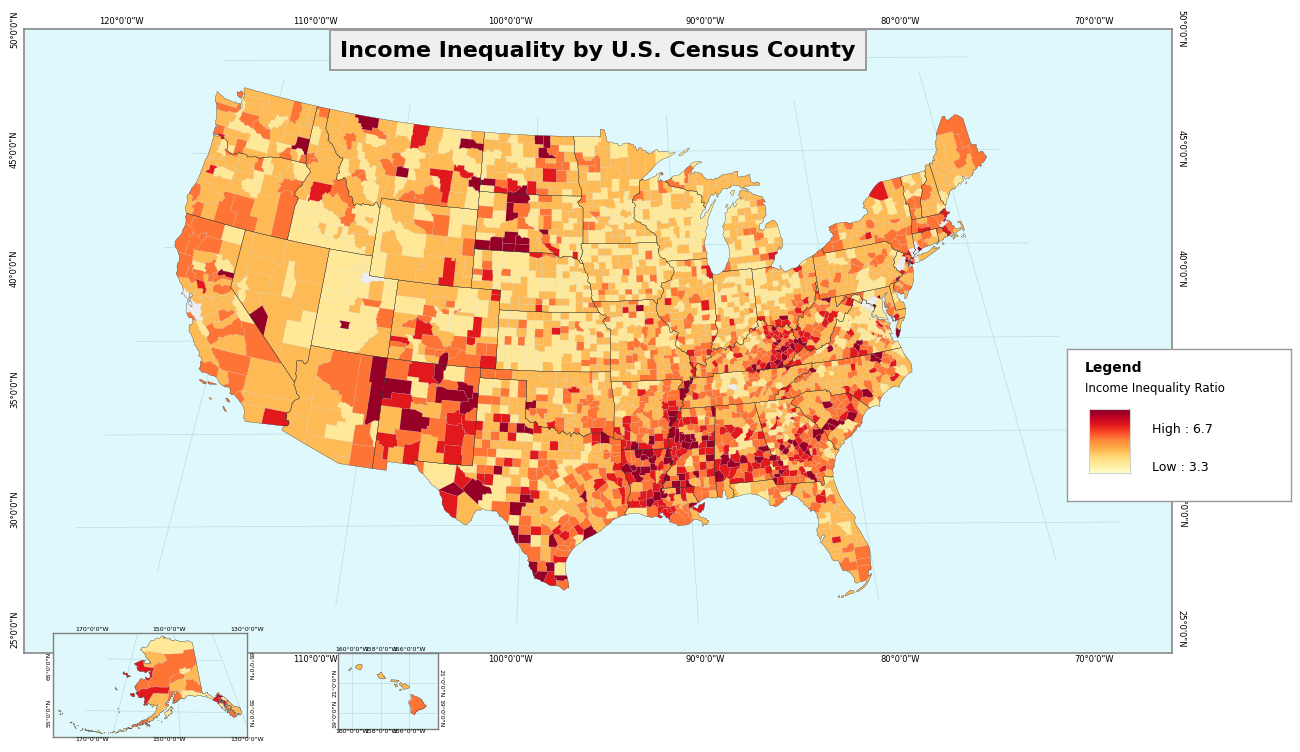

In [1]:
# Open In Colab

# Run once
# ! pip install matplotlib numpy geopandas pandas openpyxl shapely

import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import LineString

# The Income Ratio compares higher-income households to lower-income households in the same county.
# If the income ratio is 4, a household near the higher-income side,
# the 80th percentile, makes about 4 times as much as a household near the lower-income side, the 20th percentile.

file = "/content/2025 County Health Rankings Data - v4.xlsx"

# Load County Health Rankings data
excel_data = pd.read_excel(
    file,
    sheet_name="Select Measure Data",
    header=1
)

# Income inequality data
ineq = excel_data[[
    "FIPS",
    "State",
    "County",
    "80th Percentile Income",
    "20th Percentile Income",
    "Income Ratio"
]].copy()

# Keep county rows only
ineq = ineq[ineq["County"].notna()].copy()

# Clean FIPS and Income Ratio column
ineq["FIPS"] = ineq["FIPS"].astype(int).astype(str).str.zfill(5)

ineq["Income Ratio"] = pd.to_numeric(
    ineq["Income Ratio"],
    errors="coerce"
)

# Load county shapefile from U.S. Census Bureau
counties = gpd.read_file(
    "https://www2.census.gov/geo/tiger/GENZ2023/shp/cb_2023_us_county_20m.zip"
)

counties = counties.to_crs(epsg=4326)

# Merge county map with income inequality data
merged = counties.merge(
    ineq,
    left_on="GEOID",
    right_on="FIPS",
    how="left"
)

# Remove U.S. territories only
territory_codes = ["60", "66", "69", "72", "78"]
merged = merged[~merged["STATEFP"].isin(territory_codes)].copy()

# Color scale
income_values = merged["Income Ratio"].dropna()
vmin = income_values.quantile(0.02)
vmax = income_values.quantile(0.98)

# Create range bins for the map
bins = np.linspace(vmin, vmax, 6)

merged["income_bin"] = pd.cut(
    merged["Income Ratio"],
    bins=bins,
    labels=False,
    include_lowest=True
)

# Put out-of-range values into first/last bins
merged.loc[merged["Income Ratio"] < vmin, "income_bin"] = 0
merged.loc[merged["Income Ratio"] > vmax, "income_bin"] = 4

# Split into maps
lower48 = merged[~merged["STATEFP"].isin(["02", "15"])].copy()
alaska = merged[merged["STATEFP"] == "02"].copy()
hawaii = merged[merged["STATEFP"] == "15"].copy()

# Projections
lower48_proj = lower48.to_crs(epsg=5070)
alaska_proj = alaska.to_crs(epsg=3338)
hawaii_proj = hawaii.to_crs(epsg=4326)

# Create state boundary layers
lower48_states = lower48_proj.dissolve(by="STATEFP")
alaska_states = alaska_proj.dissolve(by="STATEFP")
hawaii_states = hawaii_proj.dissolve(by="STATEFP")

# Colors for income ratio bins
colors = plt.cm.YlOrRd(np.linspace(0.15, 0.95, 5))
missing_color = "#eeeeee"

# Plot each bin safely
def plot_income_map(ax, gdf, linewidth):
    missing = gdf[gdf["income_bin"].isna()]

    if not missing.empty:
        missing.plot(
            color=missing_color,
            edgecolor="lightgray",
            linewidth=linewidth,
            ax=ax,
            zorder=2
        )

    for i in range(5):
        bin_df = gdf[gdf["income_bin"] == i]

        if not bin_df.empty:
            bin_df.plot(
                color=colors[i],
                edgecolor="lightgray",
                linewidth=linewidth,
                ax=ax,
                zorder=3
            )

# Convert decimal degrees to degree-minute-second format
def decimal_to_dms(value, is_lon=True):
    if is_lon:
        direction = "W" if value < 0 else "E"
    else:
        direction = "S" if value < 0 else "N"

    value = abs(value)
    degrees = int(value)
    minutes_float = (value - degrees) * 60
    minutes = int(minutes_float)
    seconds = int(round((minutes_float - minutes) * 60))

    if seconds == 60:
        seconds = 0
        minutes += 1
    if minutes == 60:
        minutes = 0
        degrees += 1

    return f"{degrees}°{minutes}'{seconds}\"{direction}"

# Add grid lines and DMS labels on all four sides
def add_lat_lon_grid_with_dms_labels(
    ax,
    target_crs,
    lon_values,
    lat_values,
    lon_min,
    lon_max,
    lat_min,
    lat_max,
    lon_fontsize=6,
    lat_fontsize=6,
    grid_color="#8fbcc2",
    grid_alpha=0.45
):
    # Longitude grid lines and labels
    for lon in lon_values:
        line = LineString([(lon, lat_min), (lon, lat_max)])
        line_gdf = gpd.GeoDataFrame(
            geometry=[line],
            crs="EPSG:4326"
        ).to_crs(target_crs)

        line_gdf.plot(
            ax=ax,
            color=grid_color,
            linewidth=0.5,
            alpha=grid_alpha,
            zorder=1
        )

        x_frac = (lon - lon_min) / (lon_max - lon_min)
        label = decimal_to_dms(lon, is_lon=True)

        ax.text(
            x_frac, 1.004, label,
            transform=ax.transAxes,
            ha="center", va="bottom",
            fontsize=lon_fontsize,
            color="black",
            clip_on=False
        )

        ax.text(
            x_frac, -0.004, label,
            transform=ax.transAxes,
            ha="center", va="top",
            fontsize=lon_fontsize,
            color="black",
            clip_on=False
        )

    # Latitude grid lines and labels
    for lat in lat_values:
        line = LineString([(lon_min, lat), (lon_max, lat)])
        line_gdf = gpd.GeoDataFrame(
            geometry=[line],
            crs="EPSG:4326"
        ).to_crs(target_crs)

        line_gdf.plot(
            ax=ax,
            color=grid_color,
            linewidth=0.5,
            alpha=grid_alpha,
            zorder=1
        )

        y_frac = (lat - lat_min) / (lat_max - lat_min)
        label = decimal_to_dms(lat, is_lon=False)

        ax.text(
            -0.004, y_frac, label,
            transform=ax.transAxes,
            ha="right", va="center",
            rotation=90,
            fontsize=lat_fontsize,
            color="black",
            clip_on=False
        )

        ax.text(
            1.004, y_frac, label,
            transform=ax.transAxes,
            ha="left", va="center",
            rotation=270,
            fontsize=lat_fontsize,
            color="black",
            clip_on=False
        )

# Figure layout
fig = plt.figure(figsize=(14, 8), facecolor="white")

# Main map
ax_main = fig.add_axes([0.025, 0.15, 0.84, 0.78])
ax_main.set_facecolor("#dff8fb")

# Add longitude and latitude grid labels
add_lat_lon_grid_with_dms_labels(
    ax=ax_main,
    target_crs="EPSG:5070",
    lon_values=[-120, -110, -100, -90, -80, -70],
    lat_values=[25, 30, 35, 40, 45, 50],
    lon_min=-125,
    lon_max=-66,
    lat_min=24,
    lat_max=50,
    lon_fontsize=6,
    lat_fontsize=6
)

# Plot income inequality map
plot_income_map(ax_main, lower48_proj, 0.08)

# Thin black state borders
lower48_states.boundary.plot(
    ax=ax_main,
    color="black",
    linewidth=0.18,
    zorder=4
)

# Title inside the main map
ax_main.text(
    0.5,
    0.965,
    "Income Inequality by U.S. Census County",
    transform=ax_main.transAxes,
    ha="center",
    va="center",
    fontsize=16,
    fontweight="bold",
    bbox=dict(
        facecolor="#efefef",
        edgecolor="#9a9a9a",
        boxstyle="square,pad=0.45",
        linewidth=1.4
    ),
    zorder=6
)

# Add main map frame
for spine in ax_main.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.1)
    spine.set_edgecolor("#7f7f7f")

ax_main.set_xticks([])
ax_main.set_yticks([])

# Alaska inset - larger
ax_ak = fig.add_axes([0.035, 0.045, 0.18, 0.13])
ax_ak.set_facecolor("#dff8fb")

add_lat_lon_grid_with_dms_labels(
    ax=ax_ak,
    target_crs="EPSG:3338",
    lon_values=[-170, -150, -130],
    lat_values=[55, 65],
    lon_min=-180,
    lon_max=-130,
    lat_min=50,
    lat_max=72,
    lon_fontsize=4.5,
    lat_fontsize=4.5
)

plot_income_map(ax_ak, alaska_proj, 0.10)

alaska_states.boundary.plot(
    ax=ax_ak,
    color="black",
    linewidth=0.20,
    zorder=4
)

minx, miny, maxx, maxy = alaska_proj.total_bounds
x_buffer = (maxx - minx) * 0.03
y_buffer = (maxy - miny) * 0.03

ax_ak.set_xlim(minx - x_buffer, maxx + x_buffer)
ax_ak.set_ylim(miny - y_buffer, maxy + y_buffer)

for spine in ax_ak.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.0)
    spine.set_edgecolor("#7f7f7f")

ax_ak.set_xticks([])
ax_ak.set_yticks([])

# Hawaii inset - larger
ax_hi = fig.add_axes([0.235, 0.055, 0.12, 0.095])
ax_hi.set_facecolor("#dff8fb")

add_lat_lon_grid_with_dms_labels(
    ax=ax_hi,
    target_crs="EPSG:4326",
    lon_values=[-160, -158, -156],
    lat_values=[19, 21],
    lon_min=-161,
    lon_max=-154,
    lat_min=18,
    lat_max=23,
    lon_fontsize=4.5,
    lat_fontsize=4.5
)

plot_income_map(ax_hi, hawaii_proj, 0.10)

hawaii_states.boundary.plot(
    ax=ax_hi,
    color="black",
    linewidth=0.20,
    zorder=4
)

ax_hi.set_xlim(-161, -154)
ax_hi.set_ylim(18, 23)

for spine in ax_hi.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.0)
    spine.set_edgecolor("#7f7f7f")

ax_hi.set_xticks([])
ax_hi.set_yticks([])

# Legend box styled like a scale
ax_leg = fig.add_axes([0.78, 0.34, 0.16, 0.19])
ax_leg.set_facecolor("white")

for spine in ax_leg.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.0)
    spine.set_edgecolor("#9a9a9a")

ax_leg.set_xticks([])
ax_leg.set_yticks([])

# Legend title
ax_leg.text(
    0.08, 0.92,
    "Legend",
    fontsize=10,
    fontweight="bold",
    ha="left",
    va="top"
)

ax_leg.text(
    0.08, 0.78,
    "Income Inequality Ratio",
    fontsize=8.5,
    ha="left",
    va="top"
)

# Gradient color scale inside legend
scale_ax = ax_leg.inset_axes([0.10, 0.18, 0.18, 0.42])

gradient = np.linspace(vmax, vmin, 256).reshape(256, 1)

scale_ax.imshow(
    gradient,
    aspect="auto",
    cmap="YlOrRd"
)

scale_ax.set_xticks([])
scale_ax.set_yticks([])

for spine in scale_ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.8)
    spine.set_edgecolor("lightgray")

# High / Low labels
ax_leg.text(
    0.38, 0.47,
    f"High : {vmax:.1f}",
    fontsize=9,
    ha="left",
    va="center"
)

ax_leg.text(
    0.38, 0.22,
    f"Low : {vmin:.1f}",
    fontsize=9,
    ha="left",
    va="center"
)

plt.show()